### Selenium (Bitcoin Treasuries)
Using what you learned from scraping bitcointreasuries.net:

Scrape the public companies page instead of private companies and save to CSV

Compare it to the private companies data already scraped:

Which sector (public vs private) holds more Bitcoin in total?

How many companies appear in both lists? (Hint: compare the Name column)

Which country has the most companies holding Bitcoin across both lists combined?

Create one chart that visually compares public vs private company holdings in a way that is clear and easy to read

In [74]:
# Install Dependencies 

# Core scraping tools
! pip install requests beautifulsoup4 selenium

# Parser for BeautifulSoup
! pip install lxml

# Auto-manages ChromeDriver for Selenium
! pip install webdriver-manager

# Data analysis
! pip install pandas matplotlib

print("Libraries ready to import!")

'pip' is not recognized as an internal or external command,
operable program or batch file.
'pip' is not recognized as an internal or external command,
operable program or batch file.
'pip' is not recognized as an internal or external command,
operable program or batch file.
'pip' is not recognized as an internal or external command,
operable program or batch file.


Libraries ready to import!


In [75]:
import time   # For adding delays between requests

# HTTP & HTML Parsing 
import requests # Makes HTTP GET requests (like a browser)
from bs4 import BeautifulSoup  # Parses HTML 

#  Browser Automation (Selenium)
from selenium import webdriver # It lets you launch and control the browsers like you are using chrome
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# Data Handling 
import pandas as pd
import matplotlib.pyplot as plt

print("All imports successful.")

All imports successful.


In [76]:
# Configure Chrome options (Launch an headless browser)
chrome_options = Options()
chrome_options.add_argument("--headless")          
chrome_options.add_argument("--no-sandbox")         
chrome_options.add_argument("--disable-dev-shm-usage")  
chrome_options.add_argument("--disable-gpu")       
chrome_options.add_argument("--window-size=1920,1080")  

# A realistic User-Agent prevents some anti-bot measures from triggering
chrome_options.add_argument(
    "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/122.0.0.0 Safari/537.36"
)

service = Service(ChromeDriverManager().install())

driver = webdriver.Chrome(service=service, options=chrome_options)

print("Browser launched successfully!")
print(f"Chrome version: {driver.capabilities['browserVersion']}")

Browser launched successfully!
Chrome version: 146.0.7680.178


### Scrapping for private companies

In [77]:
TARGET_URL = "https://bitcointreasuries.net/private-companies"


driver.get(TARGET_URL)


wait = WebDriverWait(driver, 20)

wait.until(EC.presence_of_element_located((By.TAG_NAME, "tr")))

time.sleep(3)

print("Page loaded and data rendered!")
print(f"Current URL: {driver.current_url}")
print(f"Page title:  {driver.title}")

Page loaded and data rendered!
Current URL: https://bitcointreasuries.net/private-companies
Page title:  BitcoinTreasuries.NET - Private Companies with Bitcoin Holdings - BitcoinTreasuries


In [78]:
rendered_html = driver.page_source


soup_bt = BeautifulSoup(rendered_html, "lxml")

table = soup_bt.find("table")

if table:
    print("Table found!")
   
    rows = table.find_all("tr")
    print(f"Rows found: {len(rows)} (including header)")
else:
    print("No table found. The page may not have fully rendered.")
    print("Try increasing the sleep time in Step 3.2.")

Table found!
Rows found: 73 (including header)


In [79]:
treasury_data = []

if table:
    thead = table.find("thead")
    if thead:
        headers_row = thead.find_all("th")
        column_names = [h.get_text(strip=True) for h in headers_row]
        column_names.insert(1, "Country")
        print("Fixed columns:", column_names)
    
    tbody = table.find("tbody")
    if tbody:
        for row in tbody.find_all("tr"):
            cells = row.find_all("td")
            if len(cells) < 2:
                continue
            cell_values = [c.get_text(separator=" ", strip=True) for c in cells]
            treasury_data.append(cell_values)

print(f"Extracted {len(treasury_data)} company rows")
if treasury_data:
    print("Sample row:", treasury_data[0])

Fixed columns: ['#', 'Country', 'Name', 'Bitcoin', 'In USD', '/21M']
Extracted 71 company rows
Sample row: ['1', '🇺🇸', 'Block.one', '₿ 164,000', '$12,001M', '0.781%']


In [80]:
# Build DataFrame with the corrected column names
df_treasury = pd.DataFrame(treasury_data, columns=column_names)

# Print ALL rows — no truncation
pd.set_option("display.max_rows", None)       
pd.set_option("display.max_columns", None)    
pd.set_option("display.width", None)          
pd.set_option("display.max_colwidth", None) 

print(df_treasury.to_string(index=False))

 # Country                                  Name   Bitcoin   In USD   /21M
 1      🇺🇸                             Block.one ₿ 164,000 $12,001M 0.781%
 2      🇻🇬               Tether Holdings Limited  ₿ 96,184  $7,038M 0.458%
 3      🇺🇸            Stone Ridge Holdings Group  ₿ 10,000    $732M 0.048%
 4      🇺🇸                            SpaceX 🥬 🙌   ₿ 8,285    $606M 0.039%
 5      🇨🇭                  The Tezos Foundation   ₿ 2,903    $212M 0.014%
 6      🇺🇸                    Ionic Digital Inc.   ₿ 2,662    $195M 0.013%
 7      🇺🇸           Zap Solutions, Inc (Strike)   ₿ 1,500    $110M 0.007%
 8      🇺🇸                             GIGA Inc.   ₿ 1,252     $92M 0.006%
 9      🇫🇷                      Melanion Digital     ₿ 342     $25M 0.002%
10      🇺🇸                        Steak 'n Shake     ₿ 162     $12M 0.001%
11      🇧🇲                Meanwhile Incorporated     ₿ 123      $9M 0.001%
12      🇩🇪                         Evertz Pharma     ₿ 100      $7M 0.000%
13      🇦🇷               

In [81]:
# Build the DataFrame with the corrected 6 columns
column_names = ['#', 'Country', 'Name', 'Bitcoin', 'In USD', '/21M']

df_private = pd.DataFrame(treasury_data, columns=column_names)

print(f"DataFrame shape: {df_private.shape}")
df_private

DataFrame shape: (71, 6)


,#,Country,Name,Bitcoin,In USD,/21M
0,1,🇺🇸,Block.one,"₿ 164,000","$12,001M",0.781%
1,2,🇻🇬,Tether Holdings Limited,"₿ 96,184","$7,038M",0.458%
2,3,🇺🇸,Stone Ridge Holdings Group,"₿ 10,000",$732M,0.048%
3,4,🇺🇸,SpaceX 🥬 🙌,"₿ 8,285",$606M,0.039%
4,5,🇨🇭,The Tezos Foundation,"₿ 2,903",$212M,0.014%
5,6,🇺🇸,Ionic Digital Inc.,"₿ 2,662",$195M,0.013%
6,7,🇺🇸,"Zap Solutions, Inc (Strike)","₿ 1,500",$110M,0.007%
7,8,🇺🇸,GIGA Inc.,"₿ 1,252",$92M,0.006%
8,9,🇫🇷,Melanion Digital,₿ 342,$25M,0.002%
9,10,🇺🇸,Steak 'n Shake,₿ 162,$12M,0.001%


In [82]:
# Save the raw scraped data before any cleaning
df_treasury.to_csv("2bitcoin_treasuries_raw.csv", index=False)
print("Saved: 2bitcoin_treasuries_raw.csv")

Saved: 2bitcoin_treasuries_raw.csv


### Scrapping for public companies

In [83]:
TARGET_URL = "https://bitcointreasuries.net/public-companies"


driver.get(TARGET_URL)


wait = WebDriverWait(driver, 20)

wait.until(EC.presence_of_element_located((By.TAG_NAME, "tr")))

time.sleep(3)

print("Page loaded and data rendered!")
print(f"Current URL: {driver.current_url}")
print(f"Page title:  {driver.title}")

Page loaded and data rendered!
Current URL: https://bitcointreasuries.net/
Page title:  BitcoinTreasuries.NET - Top Bitcoin Treasury Companies


In [84]:
rendered_html = driver.page_source


soup_bt = BeautifulSoup(rendered_html, "lxml")

table = soup_bt.find("table")

if table:
    print("Table found!")
   
    rows = table.find_all("tr")
    print(f"Rows found: {len(rows)} (including header)")
else:
    print("No table found. The page may not have fully rendered.")
    print("Try increasing the sleep time in Step 3.2.")

Table found!
Rows found: 35 (including header)


In [85]:
treasury_data = []

if table:
    thead = table.find("thead")
    if thead:
        headers_row = thead.find_all("th")
        column_names = [h.get_text(strip=True) for h in headers_row]
        # column_names.insert(1, "Country")
        print("Fixed columns:", column_names)
    
    tbody = table.find("tbody")
    if tbody:
        for row in tbody.find_all("tr"):
            cells = row.find_all("td")
            if len(cells) < 2:
                continue
            cell_values = [c.get_text(separator=" ", strip=True) for c in cells]
            treasury_data.append(cell_values)

print(f"Extracted {len(treasury_data)} company rows")
if treasury_data:
    print("Sample row:", treasury_data[0])

Fixed columns: ['Rank', '', 'Country flag', 'Ticker', 'Bitcoin', '[mNAV]']
Extracted 34 company rows
Sample row: ['1', 'Strategy', '🇺🇸', 'MSTR', '766,970', '[0.84]']


In [86]:
print(len(column_names))
print(len(treasury_data[0]))
print(treasury_data[0])

6
6
['1', 'Strategy', '🇺🇸', 'MSTR', '766,970', '[0.84]']


In [87]:
# Build DataFrame
df_treasury = pd.DataFrame(treasury_data, columns=column_names)

pd.set_option("display.max_rows", None)       
pd.set_option("display.max_columns", None)    
pd.set_option("display.width", None)          
pd.set_option("display.max_colwidth", None) 

print(df_treasury.to_string(index=False))

Rank                                         Country flag Ticker Bitcoin  [mNAV]
   1                                Strategy           🇺🇸   MSTR 766,970  [0.84]
   2                      Twenty One Capital           🇺🇸    XXI  43,514  [0.72]
   3                         Metaplanet Inc.           🇯🇵  MPJPY  40,177  [1.01]
   4                     MARA Holdings, Inc.           🇺🇸   MARA  38,689  [1.61]
   5       Bitcoin Standard Treasury Company           🇺🇸   CEPO  30,021  [0.12]
   6                                 Bullish           🇺🇸   BLSH  24,300  [2.65]
   7                    Riot Platforms, Inc.           🇺🇸   RIOT  15,680  [6.19]
   8                   Coinbase Global, Inc.           🇺🇸   COIN  15,389 [41.52]
   9                                  Strive           🇺🇸   ASST  13,741  [0.68]
  10                       Hut 8 Mining Corp           🇺🇸    HUT  13,696  [7.88]
  11                        CleanSpark, Inc.           🇺🇸   CLSK  13,363  [3.33]
  12                        

In [88]:
# Build the DataFrame with corrected 6 columns
column_names = ['#', 'Country', 'Name', 'Bitcoin', 'In USD', '/21M']

df_public = pd.DataFrame(treasury_data, columns=column_names)

print(f"DataFrame shape: {df_public.shape}")
df_public

DataFrame shape: (34, 6)


,#,Country,Name,Bitcoin,In USD,/21M
0,1,Strategy,🇺🇸,MSTR,"766,970",[0.84]
1,2,Twenty One Capital,🇺🇸,XXI,"43,514",[0.72]
2,3,Metaplanet Inc.,🇯🇵,MPJPY,"40,177",[1.01]
3,4,"MARA Holdings, Inc.",🇺🇸,MARA,"38,689",[1.61]
4,5,Bitcoin Standard Treasury Company,🇺🇸,CEPO,"30,021",[0.12]
5,6,Bullish,🇺🇸,BLSH,"24,300",[2.65]
6,7,"Riot Platforms, Inc.",🇺🇸,RIOT,"15,680",[6.19]
7,8,"Coinbase Global, Inc.",🇺🇸,COIN,"15,389",[41.52]
8,9,Strive,🇺🇸,ASST,"13,741",[0.68]
9,10,Hut 8 Mining Corp,🇺🇸,HUT,"13,696",[7.88]


In [89]:
# Save the raw scraped data before any cleaning
df_treasury.to_csv("bitcoin_treasuries_raw.csv", index=False)
print("Saved: bitcoin_treasuries_raw.csv")

Saved: bitcoin_treasuries_raw.csv


In [91]:
import re

def clean_bitcoin(x):
    x = str(x)
    x = x.replace("₿", "")
    x = x.replace(",", "")
    x = x.strip()

    # fix values like ".8"
    if x.startswith("."):
        x = "0" + x

    try:
        return float(x)
    except:
        return None

In [92]:
df["bitcoin"] = df["bitcoin"].apply(clean_bitcoin)

In [93]:
df_public["type"] = "Public"

In [94]:
df_private["type"] = "Private"

### Combining both tables

In [95]:
df = pd.concat([df_public, df_private], ignore_index=True)

### Sector holding more Bitcoin
Answer: Private

In [106]:
print(df["bitcoin"].dtype)
print(df["bitcoin"].head())

float64
21       434.0
34    164000.0
35     96184.0
36     10000.0
37      8285.0
Name: bitcoin, dtype: float64


In [108]:
total_by_type = df.groupby("type")["bitcoin"].sum()

print("\n💰 Total Bitcoin by Company Type:")
print(total_by_type)

print("\n🏆 Winner:", total_by_type.idxmax())


💰 Total Bitcoin by Company Type:
type
Private    287942.1
Public        434.0
Name: bitcoin, dtype: float64

🏆 Winner: Private


### Companies appearing in both lists
Answer: no common company

In [109]:
print(df_public.columns)
print(df_private.columns)

Index(['#', 'country', 'name', 'bitcoin', 'in usd', '/21m', 'type'], dtype='str')
Index(['#', 'country', 'name', 'bitcoin', 'in usd', '/21m', 'type'], dtype='str')


In [110]:
df_private = df_private.rename(columns={
    "name": "company"
})

df_private["company"] = df_private["company"].astype(str).str.lower().str.strip()

In [114]:
df_public = df_public.rename(columns={"unnamed: 1": "name"})
df_public["company"] = df_public["name"]
private_companies = set(df_private["company"])

common_companies = public_companies.intersection(private_companies)

print("Companies appearing in BOTH lists:", len(common_companies))

Companies appearing in BOTH lists: 0


In [115]:
print("\nCommon companies:")
for c in sorted(common_companies):
    print("-", c)


Common companies:


In [116]:
from difflib import get_close_matches

matches = []

for p in public_companies:
    match = get_close_matches(p, private_companies, n=1, cutoff=0.8)
    if match:
        matches.append((p, match[0]))

print(matches)

[]


### Country which has company with most bitcoin

In [117]:
# Loading data
df_public = pd.read_csv("bitcoin_treasuries_raw.csv")
df_private = pd.read_csv("2bitcoin_treasuries_raw.csv")

# CLEANING PUBLIC

df_public.columns = df_public.columns.str.lower()

df_public = df_public.rename(columns={
    "country flag": "country"
})

df_public["country"] = df_public["country"].astype(str).str.strip()


# CLEANING PRIVATE

df_private.columns = df_private.columns.str.lower()

df_private["country"] = df_private["country"].astype(str).str.strip()

In [118]:
df_public["type"] = "Public"
df_private["type"] = "Private"

In [119]:
df = pd.concat([df_public, df_private], ignore_index=True)

In [120]:
def clean_btc(x):
    x = str(x).replace("₿", "").replace(",", "").strip()
    if x.startswith("."):
        x = "0" + x
    try:
        return float(x)
    except:
        return None

df["bitcoin"] = df["bitcoin"].apply(clean_btc)
df = df.dropna(subset=["bitcoin"])

In [121]:
country_counts = df["country"].value_counts()

print("\n🌍 Countries with most Bitcoin-holding companies:")
print(country_counts.head(10))


🌍 Countries with most Bitcoin-holding companies:
country
🇺🇸    57
🇬🇧     6
🇨🇦     4
🇨🇭     4
🇦🇹     4
🇫🇷     3
🇧🇷     2
🇩🇪     2
🇻🇬     2
🇦🇷     2
Name: count, dtype: int64


### One chart that visually comparing public vs private company holdings in a way that is clear and easy to read


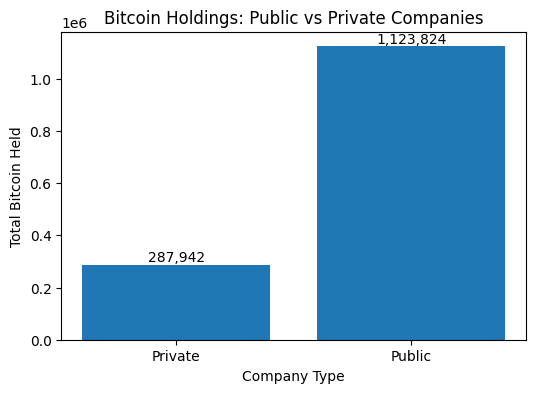

In [122]:
import matplotlib.pyplot as plt


# Standardize columns
df_public.columns = df_public.columns.str.lower()
df_private.columns = df_private.columns.str.lower()

# Adding type labels
df_public["type"] = "Public"
df_private["type"] = "Private"

# Combining
df = pd.concat([df_public, df_private], ignore_index=True)


# Cleaning Bitcoin column

def clean_btc(x):
    x = str(x).replace("₿", "").replace(",", "").strip()
    if x.startswith("."):
        x = "0" + x
    try:
        return float(x)
    except:
        return None

df["bitcoin"] = df["bitcoin"].apply(clean_btc)
df = df.dropna(subset=["bitcoin"])


# Aggregate totals

totals = df.groupby("type")["bitcoin"].sum()

# Plot

plt.figure(figsize=(6,4))
plt.bar(totals.index, totals.values)

plt.title("Bitcoin Holdings: Public vs Private Companies")
plt.ylabel("Total Bitcoin Held")
plt.xlabel("Company Type")

# add value labels on top
for i, v in enumerate(totals.values):
    plt.text(i, v, f"{int(v):,}", ha="center", va="bottom")

plt.show()

In [123]:
# Always run this immediately after you're done scraping
driver.quit()
print("Browser closed.")

Browser closed.
